In [1]:
pip install requests beautifulsoup4 pandas matplotlib schedule

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import logging
import os
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from IPython.display import display

# Enable inline plotting for Jupyter
%matplotlib inline

# Logging setup
def setup_logging():
    """Sets up logging for error tracking."""
    logging.basicConfig(filename='crypto_scraper.log', level=logging.DEBUG,
                        format='%(asctime)s - %(levelname)s - %(message)s')

# Function to scrape cryptocurrency prices
def scrape_crypto_prices(url):
    """Scrapes cryptocurrency prices from the given URL and returns a DataFrame."""
    try:
        response = requests.get(url)
        response.raise_for_status()  # Check for HTTP request errors
        soup = BeautifulSoup(response.content, 'html.parser')

        # Find the table rows containing data
        table_rows = soup.select('table tbody tr')

        crypto_data = []
        for row in table_rows:
            columns = row.find_all('td')
            if len(columns) > 2:  # Ensure row has enough columns
                crypto_name = columns[2].text.strip()  # Adjust index as per structure
                crypto_price = columns[3].text.strip().replace('$', '').replace(',', '')  # Adjust index as per structure

                # Validate and append data
                if crypto_price.replace('.', '').isdigit():
                    crypto_data.append([crypto_name, float(crypto_price)])

        if not crypto_data:
            raise ValueError("No cryptocurrency data found. Check the HTML structure.")

        df = pd.DataFrame(crypto_data, columns=['Cryptocurrency', 'Price'])
        return df

    except requests.exceptions.RequestException as e:
        logging.error(f"HTTP request error: {e}")
        print(f"HTTP request error: {e}")
    except Exception as e:
        logging.error(f"Error occurred: {e}")
        print(f"Error occurred: {e}")
        return pd.DataFrame()  # Return an empty DataFrame in case of errors

# Function to visualize cryptocurrency prices
def visualize_data(df):
    """Generates a bar chart of the top cryptocurrencies by price."""
    try:
        top_df = df.head(10)  # Display top 10 cryptocurrencies
        plt.figure(figsize=(12, 6))
        plt.bar(top_df['Cryptocurrency'], top_df['Price'], color='skyblue')
        plt.title('Top 10 Cryptocurrencies by Price')
        plt.xlabel('Cryptocurrency')
        plt.ylabel('Price (USD)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        logging.error(f"Visualization error: {e}")
        print(f"Visualization error: {e}")

# Function to visualize cryptocurrency prices as a line chart
def visualize_data(df):
    """Generates a line chart of the top cryptocurrencies by price."""
    try:
        top_df = df.head(20)  # Display top 10 cryptocurrencies
        plt.figure(figsize=(12, 6))
        plt.plot(top_df['Cryptocurrency'], top_df['Price'], marker='o', linestyle='-', color='skyblue')
        plt.title('Top 10 Cryptocurrencies by Price')
        plt.xlabel('Cryptocurrency')
        plt.ylabel('Price (USD)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        logging.error(f"Visualization error: {e}")
        print(f"Visualization error: {e}")

# Function to save data to CSV
def save_data_to_csv(df, filename='crypto_prices.csv'):
    """Saves the DataFrame to a CSV file."""
    try:
        if os.path.exists(filename):
            df.to_csv(filename, mode='a', header=False, index=False)
        else:
            df.to_csv(filename, index=False)
        print(f"Data saved to {filename}")
    except Exception as e:
        logging.error(f"CSV saving error: {e}")
        print(f"CSV saving error: {e}")

# Function to send email notifications
def send_email(subject, body, recipient, sender_email, sender_password):
    """Sends an email notification."""
    try:
        msg = MIMEMultipart()
        msg['From'] = sender_email
        msg['To'] = recipient
        msg['Subject'] = subject
        msg.attach(MIMEText(body, 'plain'))

        with smtplib.SMTP('smtp.gmail.com', 587) as server:
            server.starttls()
            server.login(sender_email, sender_password)
            server.sendmail(sender_email, recipient, msg.as_string())
        print("Email sent successfully.")
    except Exception as e:
        logging.error(f"Email sending error: {e}")
        print(f"Email sending error: {e}")

# Job function to run the scraper
def job():
    """Scrapes, visualizes, saves, and emails cryptocurrency data."""
    url = 'https://coinmarketcap.com/'
    crypto_df = scrape_crypto_prices(url)
    if not crypto_df.empty:
        print("Scraped Cryptocurrency Prices:")
        display(crypto_df)
        visualize_data(crypto_df)
        save_data_to_csv(crypto_df)
        send_email(
            subject="Daily Cryptocurrency Prices",
            body=f"Attached are the top 10 cryptocurrency prices:\n{crypto_df.head(10).to_string(index=False)}",
            recipient="jayakarthika6002@gmail.com",
            sender_email="jbitra91@gmail.com",
            sender_password="tilkozvtdtfurrgh"
        )
    else:
        print("Failed to scrape data.")


In [3]:
setup_logging()

Scraped Cryptocurrency Prices:


,Cryptocurrency,Price
0,BitcoinBTC,104435.3600
1,EthereumETH,3867.9400
2,XRPXRP,2.4700
3,TetherUSDT,0.9997
4,SolanaSOL,217.5300
...,...,...
95,BitTorrent [New]BTT,0.0000
96,MultiversXEGLD,41.3400
97,XDC NetworkXDC,0.0800
98,CoreCORE,1.2100


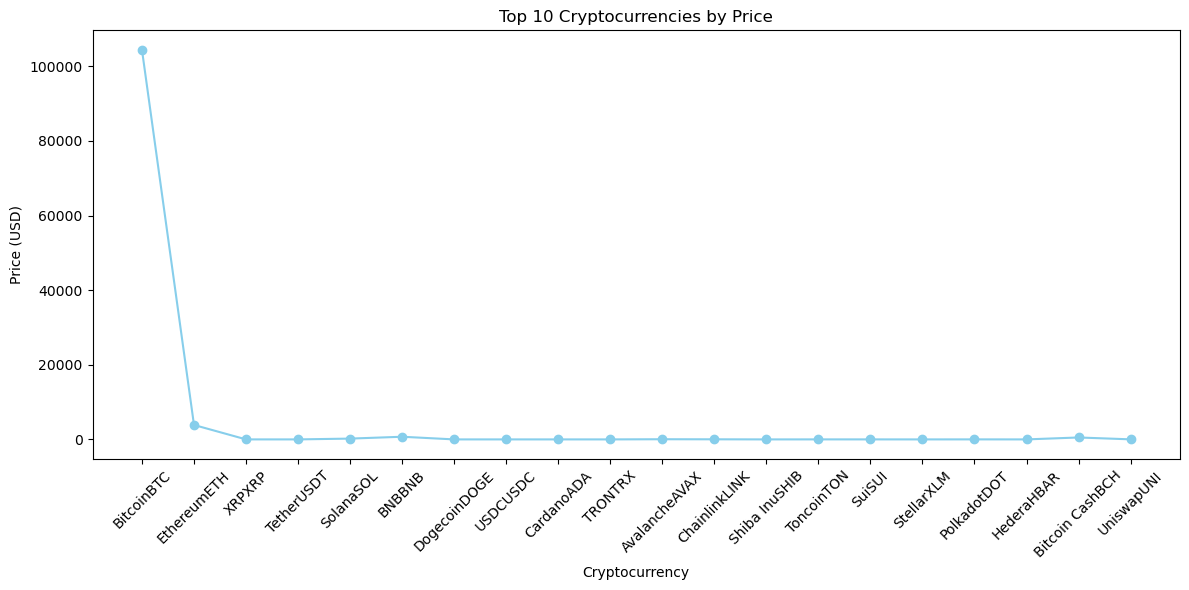

Data saved to crypto_prices.csv
Email sent successfully.


In [4]:
job()

In [5]:
pd.read_csv('crypto_prices.csv').head()

,Cryptocurrency,Price
0,BitcoinBTC,95554.86
1,EthereumETH,3627.58
2,TetherUSDT,1.00
3,SolanaSOL,237.17
4,BNBBNB,658.38


In [6]:
pd.read_csv('crypto_prices.csv').tail()

,Cryptocurrency,Price
295,BitTorrent [New]BTT,0.00
296,MultiversXEGLD,41.34
297,XDC NetworkXDC,0.08
298,CoreCORE,1.21
299,EigenLayerEIGEN,5.28


In [7]:
scrape_crypto_prices

<function __main__.scrape_crypto_prices(url)>

In [8]:
visualize_data

<function __main__.visualize_data(df)>

In [9]:
save_data_to_csv

<function __main__.save_data_to_csv(df, filename='crypto_prices.csv')>